# 🏦 Mule Account Detection System (Maestro Fintech)
**Objective:** Train a deep neural network to detect synthetic identity fraud (money mules) by analyzing transactional velocity and balance differentials. 

* **Dataset:** PaySim Synthetic Financial Dataset (6.3M records)
* **Target:** `isFraud` (Binary Classification)
* **Goal:** Maximize **Recall** to prevent illicit funds from bypassing the AML system.

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import tensorflow as tf

# Keras 3 standalone imports (Fixes the VS Code warning)
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


## 1. Data Loading & Feature Engineering
Mule accounts are characterized by rapid inflow and outflow. We will engineer `balance_diff_orig` and `balance_diff_dest` to mathematically capture the abrupt drainage and filling of accounts.

In [5]:
# Load Data (Replace with your path or sample dataset)
# df = pd.read_csv('../data/paysim_dataset.csv') 
df = pd.read_csv('~/mule-account-detection/data/fraud_dataset.csv') # Using sample for GitHub constraint demonstration

print(f"Dataset Shape: {df.shape}")

# 1. Feature Engineering: Capture abrupt account drainage
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['oldbalanceDest'] - df['newbalanceDest']

# 2. Categorical Encoding: One-Hot Encode transaction types
df = pd.get_dummies(df, columns=['type'], drop_first=True)

# 3. Drop Identifiers: The model cannot learn from alphanumeric strings
X = df.drop(['isFraud', 'isFlaggedFraud', 'nameOrig', 'nameDest', 'step'], axis=1, errors='ignore')
y = df['isFraud']

# Ensure all data is float32 for TensorFlow
X = X.astype('float32')

print(f"Features ready for training: {X.columns.tolist()}")

Dataset Shape: (6362620, 11)
Features ready for training: ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balance_diff_orig', 'balance_diff_dest', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


## 2. Stratified Splitting & Standardization
Because the dataset is highly imbalanced (~0.13% fraud), we must use a stratified split to ensure fraud cases are evenly distributed between the training and testing sets. We then apply `StandardScaler` to prevent large currency values from destabilizing the neural network.

In [6]:
# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (5090096, 11)
Testing data shape: (1272524, 11)


## 3. Handling Extreme Imbalance
Instead of computationally heavy over-sampling (SMOTE) which could bottleneck the cloud instance, we utilize **Class Weighting**. This instructs TensorFlow to heavily penalize errors made on the minority (Fraud) class.

In [7]:
# Calculate class weights
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train) 
class_weights = dict(enumerate(weights))

print("Applied Class Weights:")
print(f"Normal Transaction (0): {class_weights[0]:.4f}")
print(f"Fraudulent Mule (1): {class_weights[1]:.4f}")

Applied Class Weights:
Normal Transaction (0): 0.5006
Fraudulent Mule (1): 387.3741


## 4. Deep Neural Network Architecture
The architecture utilizes multiple Dense layers with ReLU activation to capture complex non-linear routing patterns. Dropout layers are included for regularization. The final layer uses a Sigmoid activation function to output a probability score between 0.0 and 1.0.

In [8]:
# Define the Keras Sequential Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3), 
    
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    Dense(16, activation='relu'),
    
    Dense(1, activation='sigmoid') 
])

# Define custom metrics to track business-critical performance
metrics = [
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.AUC(name='auc')
]

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='binary_crossentropy', 
    metrics=metrics
)

model.summary()

E0000 00:00:1777150221.799948    6180 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Model Training with Early Stopping
We utilize Early Stopping to monitor the Validation Recall. If the model stops improving its ability to catch fraud, training automatically halts to conserve AWS EC2 compute resources.

In [9]:
# Set up early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_recall', 
    patience=5,          
    mode='max',          
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=2048, 
    validation_split=0.2,
    class_weight=class_weights, 
    callbacks=[early_stopping],
    verbose=1
)

W0000 00:00:1777150232.267935    6180 cpu_allocator_impl.cc:82] Allocation of 179171344 exceeds 10% of free system memory.


Epoch 1/50
1989/1989 ━━━━━━━━━━━━━━━━━━━━ 79s 34ms/step - auc: 0.9805 - loss: 0.1892 - precision: 0.0171 - recall: 0.9308 - val_auc: 0.9923 - val_loss: 0.1385 - val_precision: 0.0215 - val_recall: 0.9867
Epoch 2/50
1989/1989 ━━━━━━━━━━━━━━━━━━━━ 66s 32ms/step - auc: 0.9913 - loss: 0.1185 - precision: 0.0234 - recall: 0.9658 - val_auc: 0.9944 - val_loss: 0.0806 - val_precision: 0.0317 - val_recall: 0.9789
Epoch 3/50
1989/1989 ━━━━━━━━━━━━━━━━━━━━ 66s 33ms/step - auc: 0.9934 - loss: 0.1015 - precision: 0.0280 - recall: 0.9726 - val_auc: 0.9954 - val_loss: 0.0878 - val_precision: 0.0313 - val_recall: 0.9899
Epoch 4/50
1989/1989 ━━━━━━━━━━━━━━━━━━━━ 56s 28ms/step - auc: 0.9940 - loss: 0.0905 - precision: 0.0319 - recall: 0.9760 - val_auc: 0.9957 - val_loss: 0.1115 - val_precision: 0.0259 - val_recall: 0.9922
Epoch 5/50
1989/1989 ━━━━━━━━━━━━━━━━━━━━ 90s 31ms/step - auc: 0.9949 - loss: 0.0836 - precision: 0.0350 - recall: 0.9773 - val_auc: 0.9961 - val_loss: 0.0724 - val_precision: 0.0388 -

## 6. Evaluation & Confusion Matrix
Testing the model on the unseen 20% validation split. Our primary business objective is maximizing the Recall score.

39767/39767 ━━━━━━━━━━━━━━━━━━━━ 243s 6ms/step

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.98   1270881
Mule Account       0.03      0.99      0.05      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.97      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524



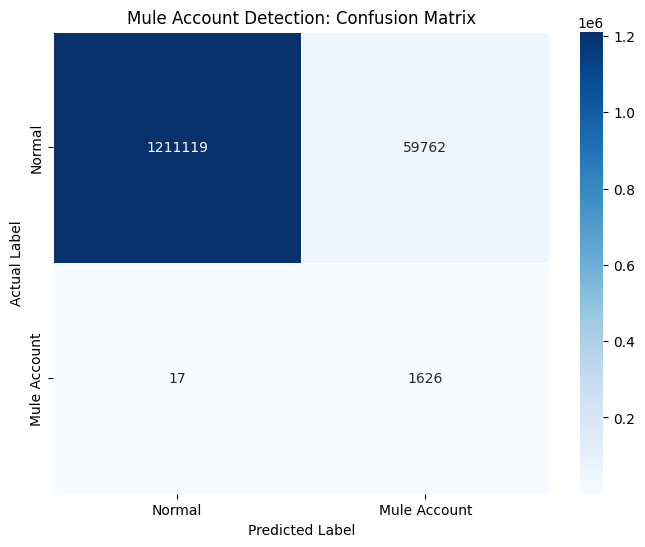

In [10]:
# Generate predictions on the test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# Print Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Mule Account']))

# Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            xticklabels=['Normal', 'Mule Account'], 
            yticklabels=['Normal', 'Mule Account'])
plt.title('Mule Account Detection: Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## 7. Artifact Serialization for API Deployment
Saving the trained deep learning model and the fitted standard scaler so they can be loaded into the Dockerized Flask microservice.

In [11]:
# Save the model artifact
model.save('../api/mule_detection_model.keras')

# Save the scaler artifact
joblib.dump(scaler, '../api/scaler.pkl')

print("Deployment artifacts saved successfully to the /api directory.")

Deployment artifacts saved successfully to the /api directory.
